In [1]:
# !pip install pandas matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

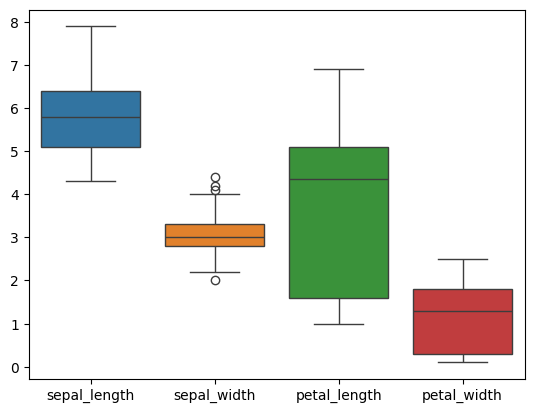

In [6]:
sns.boxplot(data)

In [7]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
X = data.drop("species", axis=1)
y = data['species']

In [9]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y = le.fit_transform(y)

In [10]:
y = pd.get_dummies(y)
y

,Iris-setosa,Iris-versicolor,Iris-virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
145,False,False,True
146,False,False,True
147,False,False,True
148,False,False,True


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [14]:
y_train

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
mms = MinMaxScaler()
train_temp = mms.fit_transform(X_train)
test_temp = mms.transform(X_test)
mms_X_train = pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test = pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [17]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [18]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


In [19]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


# 텐서플로로 다중분류 분석하기

Sequencial API

In [20]:
from keras.models import Sequential
from keras.layers import Dense, Input

2025-05-19 02:45:57.945301: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 02:45:58.143901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-19 02:45:58.224734: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-19 02:45:58.247797: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-19 02:45:58.378687: I tensorflow/core/platform/cpu_feature_guar

In [21]:
model = Sequential()
model.add(Input(shape=(mms_X_train.shape[1], )))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(3, activation="softmax"))
model.summary()

I0000 00:00:1747622761.498886      72 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747622761.548928      72 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747622761.549011      72 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747622761.554265      72 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747622761.554325      72 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
  * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
  * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

Epoch 1/100


I0000 00:00:1747622763.510745     169 service.cc:146] XLA service 0x7fccbc0059b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747622763.510778     169 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-05-19 02:46:03.538944: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-19 02:46:03.683003: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


1/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3125 - loss: 1.1065

I0000 00:00:1747622764.631018     169 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 211ms/step - accuracy: 0.3316 - loss: 1.0992 - val_accuracy: 0.3000 - val_loss: 1.1011
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4077 - loss: 1.0880 - val_accuracy: 0.6000 - val_loss: 1.0908
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6810 - loss: 1.0750 - val_accuracy: 0.6333 - val_loss: 1.0808
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6601 - loss: 1.0727 - val_accuracy: 0.6333 - val_loss: 1.0726
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6728 - loss: 1.0607 - val_accuracy: 0.6333 - val_loss: 1.0655
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6725 - loss: 1.0524 - val_accuracy: 0.6333 - val_loss: 1.0571
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6354 - loss: 1.0512 - val_accuracy: 0.6333 - val_loss: 1.0476
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6706 - loss: 1.0342 - val_accuracy: 0.6333 - val_loss: 1.0366
Epo

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6724 - loss: 0.5143 - val_accuracy: 0.6333 - val_loss: 0.5183
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6982 - loss: 0.4747 - val_accuracy: 0.6333 - val_loss: 0.5122
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6699 - loss: 0.5301 - val_accuracy: 0.6333 - val_loss: 0.5074
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6974 - loss: 0.4680 - val_accuracy: 0.6333 - val_loss: 0.5010
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6781 - loss: 0.4995 - val_accuracy: 0.6333 - val_loss: 0.4947
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6522 - loss: 0.4821 - val_accuracy: 0.6333 - val_loss: 0.4882
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7120 - loss: 0.4726 - val_accuracy: 0.6333 - val_loss: 0.4830
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6701 - loss: 0.4687 - val_accuracy: 0.6333 - val_loss: 0.47

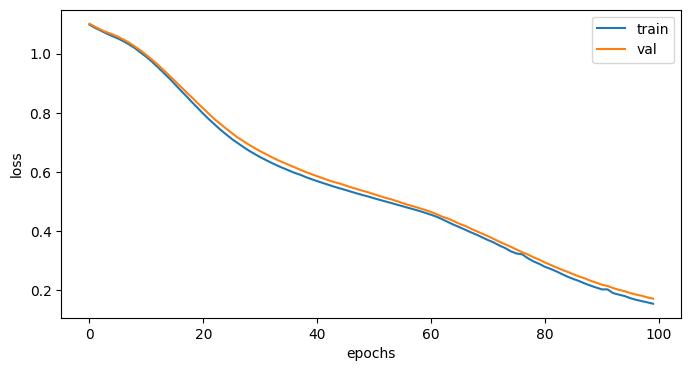

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.004055,0.830689,1.652556e-01
18,True,False,False,0.998742,0.001258,3.857242e-08
118,False,False,True,0.000005,0.074151,9.258447e-01
78,False,True,False,0.003340,0.768165,2.284949e-01
76,False,True,False,0.001562,0.705960,2.924778e-01
31,True,False,False,0.997295,0.002705,2.217943e-07
64,False,True,False,0.019992,0.942697,3.731190e-02
141,False,False,True,0.000071,0.157044,8.428853e-01
68,False,True,False,0.000563,0.303294,6.961429e-01
82,False,True,False,0.011864,0.915312,7.282468e-02


In [22]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

In [23]:
y_test

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [24]:
pd.DataFrame(pred)

,0,1,2
73,0.004055,0.830689,1.652556e-01
18,0.998742,0.001258,3.857242e-08
118,0.000005,0.074151,9.258447e-01
78,0.003340,0.768165,2.284949e-01
76,0.001562,0.705960,2.924778e-01
31,0.997295,0.002705,2.217943e-07
64,0.019992,0.942697,3.731190e-02
141,0.000071,0.157044,8.428853e-01
68,0.000563,0.303294,6.961429e-01
82,0.011864,0.915312,7.282468e-02


Functional API

In [25]:
from keras.models import Model

In [26]:
inputs = Input(shape=(mms_X_train.shape[1],))
x = Dense(16, activation='relu')(inputs)
x = Dense(8, activation='relu')(x)
x = Dense(4, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.3085 - loss: 1.3285 - val_accuracy: 0.3333 - val_loss: 1.2792
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2980 - loss: 1.2311 - val_accuracy: 0.3333 - val_loss: 1.2234
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2972 - loss: 1.1878 - val_accuracy: 0.3333 - val_loss: 1.1887
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2849 - loss: 1.1588 - val_accuracy: 0.3333 - val_loss: 1.1584
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3147 - loss: 1.1321 - val_accuracy: 0.3333 - val_loss: 1.1304
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3745 - loss: 1.1000 - val_accuracy: 0.4333 - val_loss: 1.1043
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4292 - loss: 1.0845 - val_accuracy: 0.5000 - val_loss: 1.0798
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5454 - loss: 1.0689 - val_accuracy: 0.5667 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9852 - loss: 0.3344 - val_accuracy: 0.9333 - val_loss: 0.3410
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9743 - loss: 0.3390 - val_accuracy: 0.9667 - val_loss: 0.3327
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9642 - loss: 0.3099 - val_accuracy: 0.9333 - val_loss: 0.3234
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9730 - loss: 0.3283 - val_accuracy: 0.9333 - val_loss: 0.3156
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9603 - loss: 0.3430 - val_accuracy: 0.9333 - val_loss: 0.3067
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9928 - loss: 0.2770 - val_accuracy: 0.9667 - val_loss: 0.2988
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9941 - loss: 0.2879 - val_accuracy: 0.9333 - val_loss: 0.2911
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9723 - loss: 0.2769 - val_accuracy: 0.9333 - v

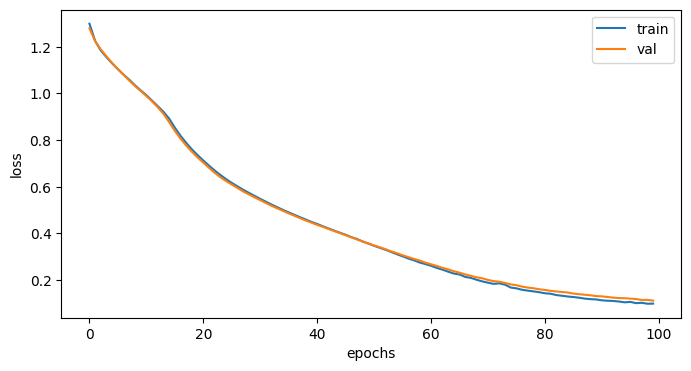

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.006286,0.920779,7.293534e-02
18,True,False,False,0.998166,0.001834,3.050959e-12
118,False,False,True,0.000003,0.022345,9.776518e-01
78,False,True,False,0.004497,0.860485,1.350175e-01
76,False,True,False,0.003009,0.857943,1.390478e-01
31,True,False,False,0.995913,0.004087,4.629956e-11
64,False,True,False,0.018643,0.974757,6.599492e-03
141,False,False,True,0.000053,0.086846,9.131005e-01
68,False,True,False,0.001257,0.369036,6.297075e-01
82,False,True,False,0.014154,0.969315,1.653126e-02


In [27]:
model.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result

Subclass API

In [28]:
class Iris(Model):
    def __init__(self):
        super(Iris, self).__init__()
        self.dense1 =Dense(16, activation='relu')
        self.dense2 =Dense(8, activation='relu')
        self.dense3 =Dense(4, activation='relu')
        self.classifier = Dense(3, activation='softmax')
        
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        return self.classifier(x)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.5662 - loss: 1.1145 - val_accuracy: 0.6333 - val_loss: 1.1140
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6684 - loss: 1.0995 - val_accuracy: 0.6333 - val_loss: 1.1045
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5817 - loss: 1.1037 - val_accuracy: 0.6333 - val_loss: 1.0972
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6983 - loss: 1.0892 - val_accuracy: 0.6333 - val_loss: 1.0936
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6753 - loss: 1.0879 - val_accuracy: 0.6333 - val_loss: 1.0907
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7043 - loss: 1.0829 - val_accuracy: 0.6333 - val_loss: 1.0874
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6716 - loss: 1.0810 - val_accuracy: 0.6333 - val_loss: 1.0836
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6649 - loss: 1.0790 - val_accuracy: 0.6333 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9070 - loss: 0.5636 - val_accuracy: 0.8667 - val_loss: 0.5539
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9212 - loss: 0.5488 - val_accuracy: 0.8667 - val_loss: 0.5471
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9376 - loss: 0.4767 - val_accuracy: 0.8667 - val_loss: 0.5428
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9116 - loss: 0.5812 - val_accuracy: 0.8667 - val_loss: 0.5323
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9498 - loss: 0.5138 - val_accuracy: 0.8667 - val_loss: 0.5333
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9493 - loss: 0.4719 - val_accuracy: 0.8667 - val_loss: 0.5196
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9432 - loss: 0.4681 - val_accuracy: 0.8667 - val_loss: 0.5165
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9557 - loss: 0.4830 - val_accuracy: 0.8667 - v

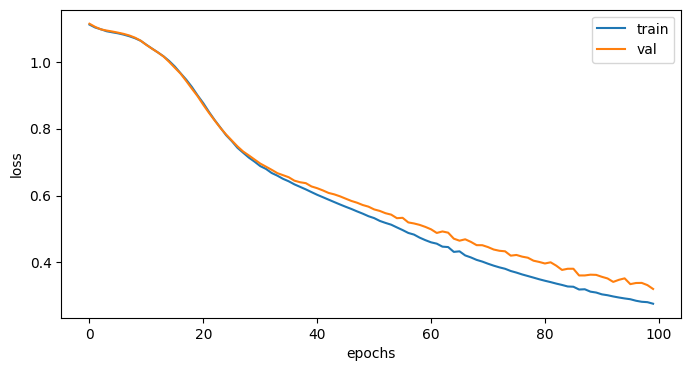

,Iris-setosa,Iris-versicolor,Iris-virginica,0,1,2
73,False,True,False,0.075903,0.879403,0.044693
18,True,False,False,0.997713,0.002240,0.000047
118,False,False,True,0.155047,0.297432,0.547521
78,False,True,False,0.102188,0.806079,0.091733
76,False,True,False,0.127299,0.704515,0.168186
31,True,False,False,0.994085,0.005761,0.000154
64,False,True,False,0.029061,0.965599,0.005339
141,False,False,True,0.155047,0.297432,0.547521
68,False,True,False,0.152328,0.310253,0.537419
82,False,True,False,0.048659,0.935145,0.016196


In [29]:
model2 = Iris()
model2.compile(loss="categorical_crossentropy", optimizer='adam', metrics=['accuracy'])
history = model2.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                    validation_data=(mms_X_test, y_test))
pred = model2.predict(mms_X_test)
pred = pd.DataFrame(pred, index=y_test.index)
result = pd.concat([y_test, pred], axis=1)
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'val'])
plt.show()
result